# Does graph context add information?

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import display, Image, Markdown
ROOT = Path.cwd()
if not (ROOT / "config.json").exists():
    ROOT = ROOT.parent
REPORTS = ROOT / "reports"
assert (REPORTS / "run_manifest.json").exists(), "Run python -m fraudgraph.pipeline --download first"
manifest = json.loads((REPORTS / "run_manifest.json").read_text())
print("Evidence run:", manifest["run_id"])
def figure(name):
    display(Image(filename=str(REPORTS / "figures" / name)))


Evidence run: 20260923T163139886696Z


,experiment_id,pr_auc_ap,precision,recall,false_positive_rate,tp,fp,fn,tn
1,named_logistic_tx,0.090574,0.084102,0.831761,0.546170,529,5761,107,4787
3,named_logistic_graph,0.069606,0.075865,0.641509,0.471179,408,4970,228,5578
5,named_xgboost_tx,0.423938,0.728000,0.429245,0.009670,273,102,363,10446
7,named_xgboost_graph,0.523974,0.735084,0.484277,0.010523,308,111,328,10437
9,extended_logistic_tx,0.149566,0.202393,0.638365,0.151688,406,1600,230,8948
11,extended_logistic_graph,0.116216,0.141919,0.339623,0.123815,216,1306,420,9242
13,extended_xgboost_tx,0.634914,0.846547,0.520440,0.005688,331,60,305,10488
15,extended_xgboost_graph,0.639790,0.814118,0.544025,0.007490,346,79,290,10469


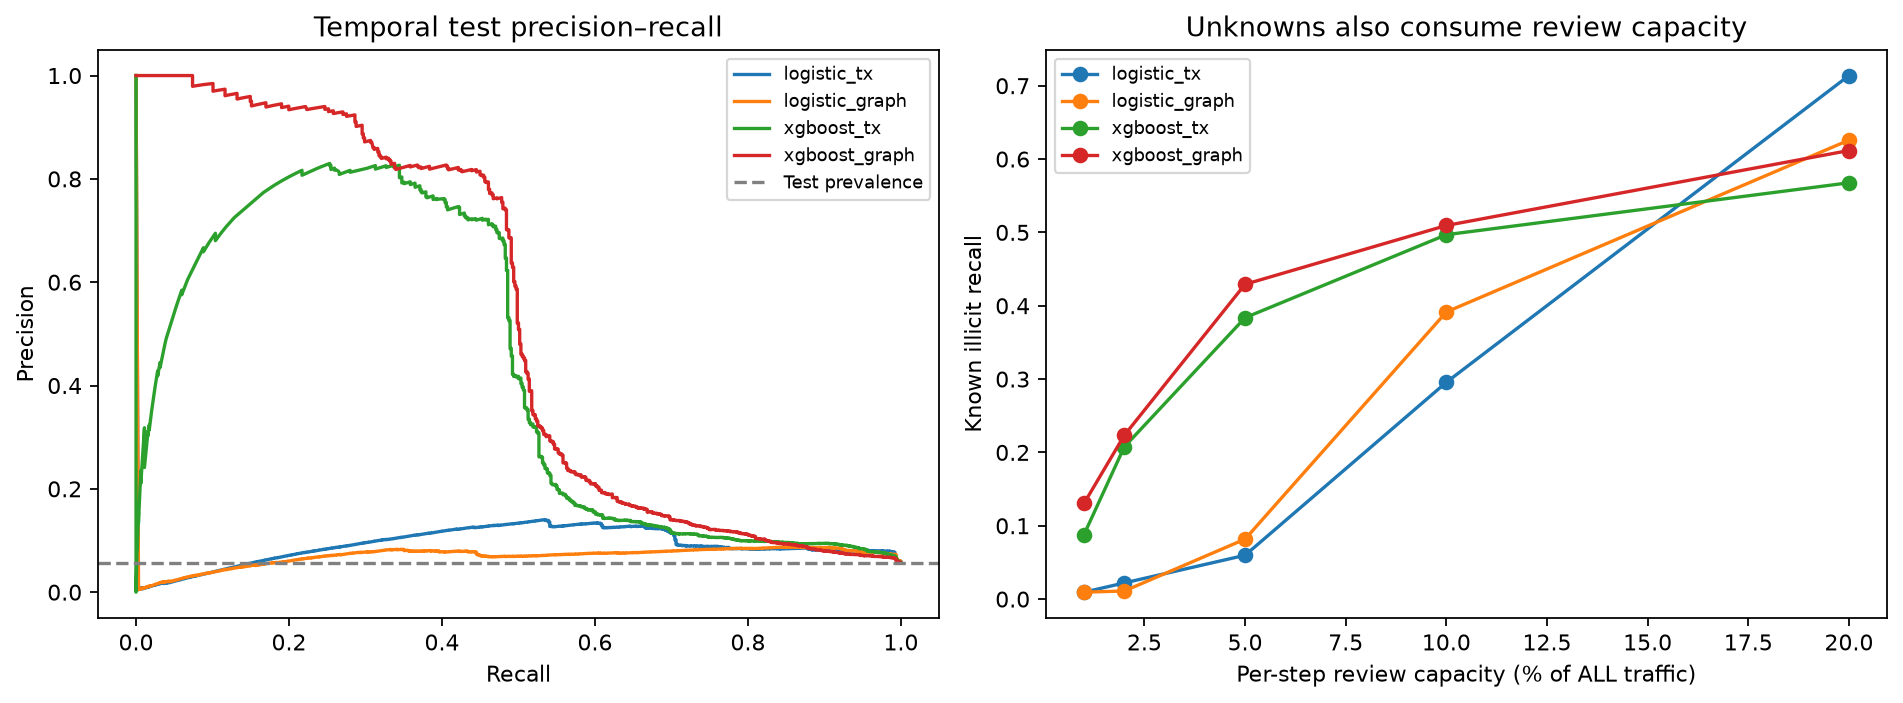

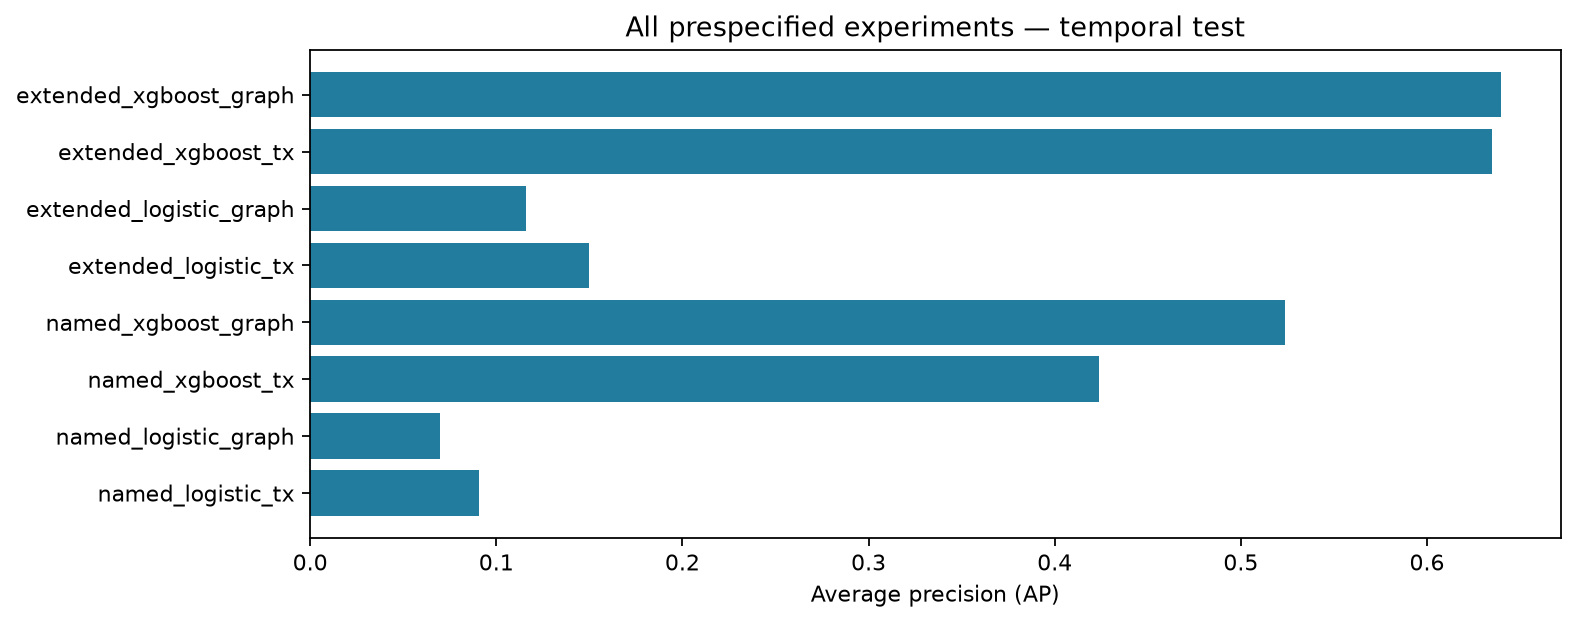

In [2]:
r = pd.read_csv(REPORTS / "results.csv")
display(r[r.split == "test"][["experiment_id","pr_auc_ap","precision","recall","false_positive_rate","tp","fp","fn","tn"]])
figure("model_comparison.png")
figure("all_experiments.png")

,delta_ap,ci_95_low,ci_95_high,repetitions,valid_repetitions,unit,seed
named_logistic,-0.020968,-0.055248,0.013736,1000,1000,time bucket,42
named_xgboost,0.100035,0.001501,0.136537,1000,1000,time bucket,42
extended_logistic,-0.033349,-0.103466,0.014624,1000,1000,time bucket,42
extended_xgboost,0.004876,-0.000797,0.011509,1000,1000,time bucket,42


,cohort,experiment_id,n,illicit,ap
0,all_labeled_test,named_logistic_tx,11184,636,0.090574
1,all_labeled_test,named_logistic_graph,11184,636,0.069606
2,all_labeled_test,named_xgboost_tx,11184,636,0.423938
3,all_labeled_test,named_xgboost_graph,11184,636,0.523974
4,all_labeled_test,extended_logistic_tx,11184,636,0.149566
5,all_labeled_test,extended_logistic_graph,11184,636,0.116216
6,all_labeled_test,extended_xgboost_tx,11184,636,0.634914
7,all_labeled_test,extended_xgboost_graph,11184,636,0.639790
8,exclude_train_fingerprints,named_logistic_tx,11074,636,0.090580
9,exclude_train_fingerprints,named_logistic_graph,11074,636,0.069864


,experiment_id,split,threshold,pr_auc_ap,precision,recall,f1,false_positive_rate,tn,fp,fn,tp,precision_at_5pct_known,recall_at_5pct_known,notes
0,diagnostic_named_xgboost_degree_only,validation,0.680885,0.758775,0.878453,0.612717,0.721907,0.011054,7873,88,402,636,0.798246,0.350674,Post-hoc structural ablation; same splits and ...
1,diagnostic_named_xgboost_degree_only,test,0.680885,0.468313,0.730978,0.422956,0.535857,0.009386,10449,99,367,269,0.374113,0.331761,Post-hoc structural ablation; same splits and ...
2,diagnostic_named_xgboost_without_component,validation,0.646031,0.779128,0.885445,0.632948,0.738202,0.010677,7876,85,381,657,0.804825,0.353565,Post-hoc structural ablation; same splits and ...
3,diagnostic_named_xgboost_without_component,test,0.646031,0.505671,0.751880,0.471698,0.579710,0.009386,10449,99,336,300,0.381206,0.338050,Post-hoc structural ablation; same splits and ...


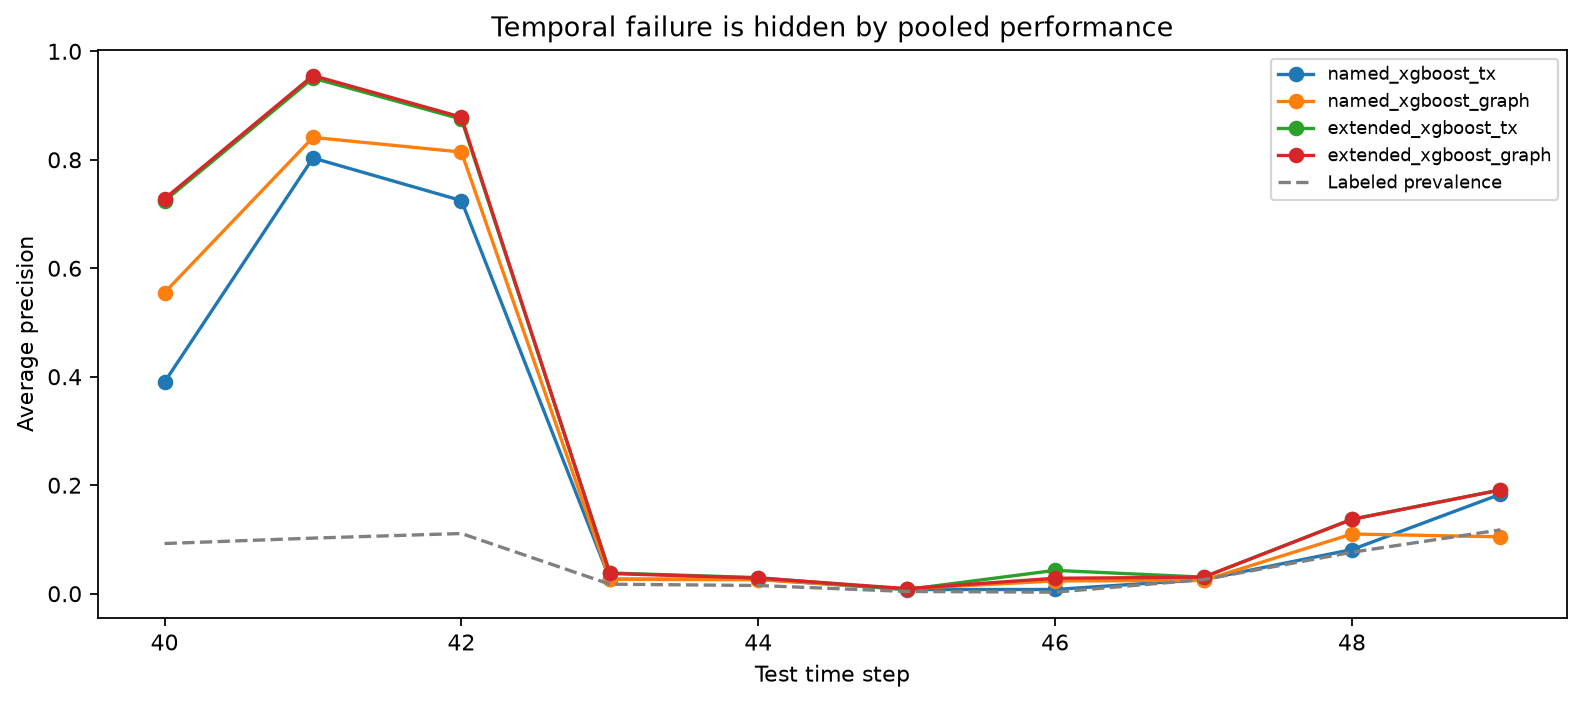

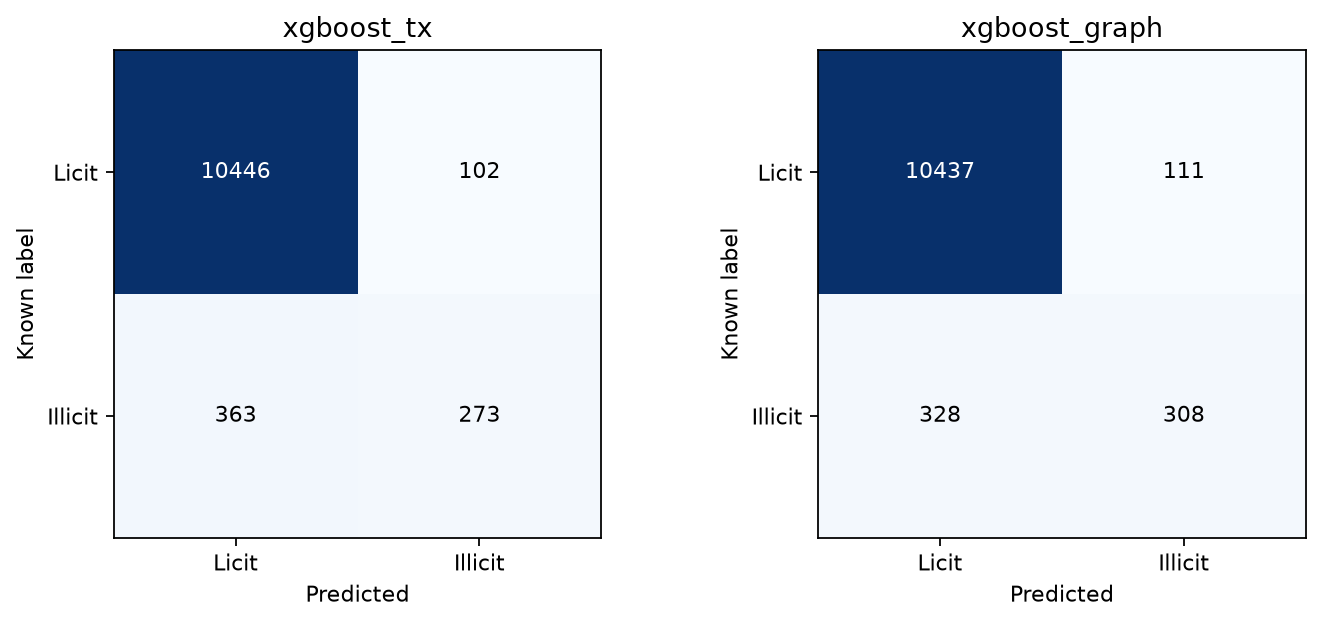

experiment_id            diagnostic_shuffled_labels_extended_xgboost_graph
split                                                           validation
model                                                              xgboost
pr_auc_ap                                                         0.097798
validation_prevalence                                             0.115346
seed                                                                    42
notes                    Post-hoc negative control; train labels shuffl...
dtype: object

In [3]:
display(pd.DataFrame(json.loads((REPORTS / "paired_comparison.json").read_text())).T)
display(pd.read_csv(REPORTS / "robustness.csv"))
display(pd.read_csv(REPORTS / "structural_ablations.csv"))
figure("temporal_generalization.png")
figure("confusion_matrices.png")
display(pd.Series(json.loads((REPORTS / "negative_control.json").read_text())).drop(["feature_set","parameters"]))

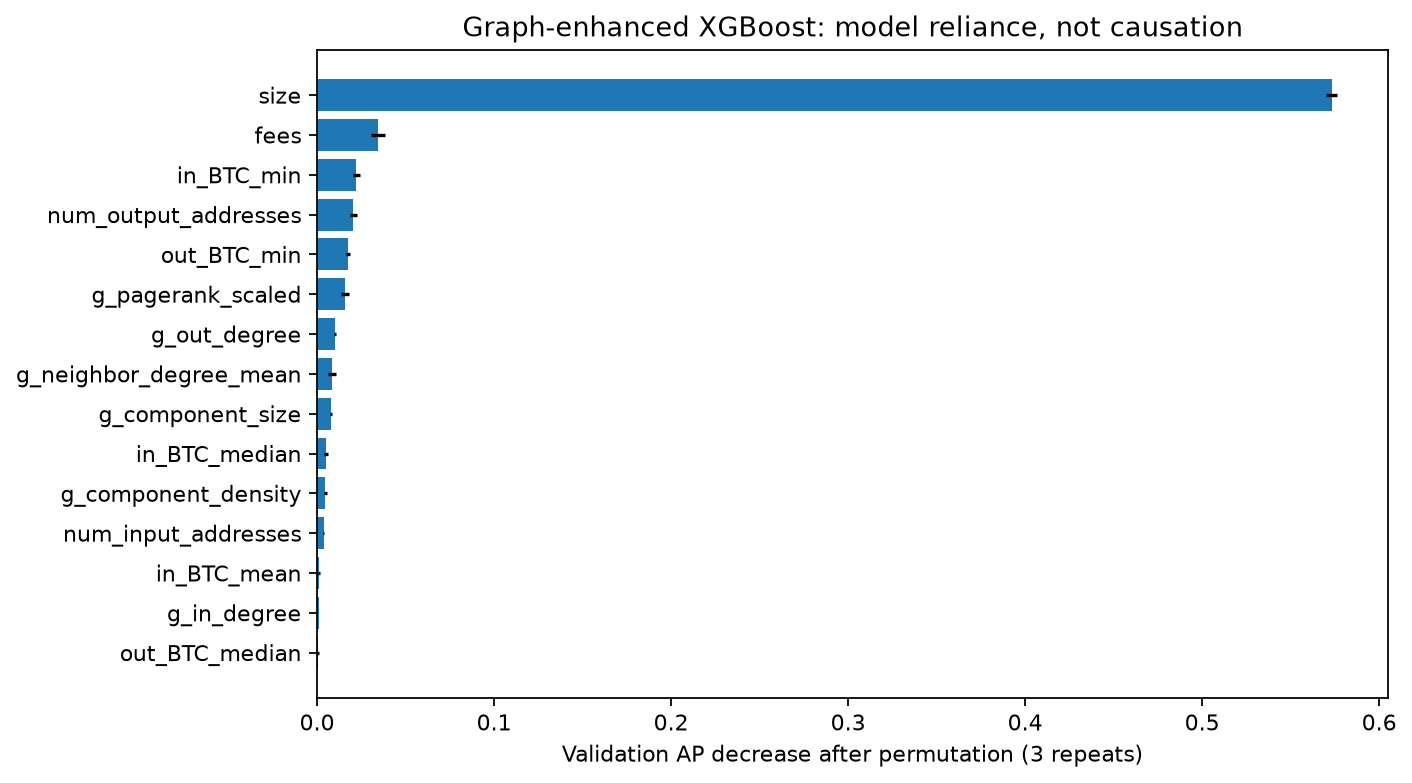

Transaction 12662327 — top signed log-odds contributions


size                    3.297181
fees                    1.024241
num_output_addresses    0.407060
g_component_size        0.324834
out_BTC_min             0.311323
Name: 12662327, dtype: float64

Transaction 72687354 — top signed log-odds contributions


size                    3.648304
fees                    0.583948
num_output_addresses    0.489680
g_out_degree            0.245066
out_BTC_min            -0.230127
Name: 72687354, dtype: float64

Transaction 12661223 — top signed log-odds contributions


size                2.533505
in_BTC_min         -1.086101
fees                0.772556
g_component_size    0.399005
in_BTC_median      -0.388238
Name: 12661223, dtype: float64

In [4]:
figure("feature_importance.png")
shap = pd.read_csv(REPORTS / "case_shap_logodds.csv").set_index("txId")
for tx, contributions in shap.iterrows():
    print("Transaction", tx, "— top signed log-odds contributions")
    names = contributions.drop("bias").abs().nlargest(5).index
    display(contributions[names])

Graph context improves the named-attribute boosted model, but its incremental gain is much smaller with the stronger local-feature baseline. Logistic graph variants deteriorate on test. Permutation importance measures model reliance under correlated predictors; TreeSHAP contributions sum to a model margin, not a causal explanation or a verified criminal motive.